# 📡 CSI-Based Indoor Localization — MIMO Router Regression (Final)
## 16 Positions | 4×4 Grid | ASUS RT-AC86U (bcm4366c0)

**Four toggles in Config cell control everything:**

| Toggle | Options | Effect |
|---|---|---|
| `SPLIT_TYPE` | `'spatial'` / `'random'` | Outer/inner split vs random 80/20 |
| `FEATURE_TYPE` | `'stats'` / `'raw'` | 6 statistical features vs 63 raw amp² |
| `ENABLE_MRC` | `True` / `False` | Include/exclude MRC strategy |
| `ENABLE_RF` | `True` / `False` | Include/exclude RF alongside ANN |

**Feature counts by FEATURE_TYPE:**

| FEATURE_TYPE | 1-Ant | MRC | 4-Ant |
|---|---|---|---|
| `'stats'` | 6 | 6 | 24 |
| `'raw'` | 63 | 63 | 252 |

**Amplitude squared BEFORE windowing** — consistent with old 3-AP regression notebook.

## Step 1: Configuration — All Toggles Here

In [ ]:
import os, sys

# ── Directory paths ────────────────────────────────────────────────────────────
PARSER_DIR   = os.path.expanduser('~/parser_check')
CAPTURES_DIR = os.path.expanduser('~/captures/16pos_experiment')
DATA_DIR     = os.path.expanduser('~/data')
OUTPUT_DIR   = os.path.expanduser('~/localization')

# ── ESP32-C5 transmitter MAC ───────────────────────────────────────────────────
ESP32_MAC = 'd0:cf:13:e2:88:94'

# ── Windowing ──────────────────────────────────────────────────────────────────
WINDOW = 1   # 15 → stable samples matching old 3-AP notebook

# ── Hardware constants ─────────────────────────────────────────────────────────
N_CORES = 4
N_SUB   = 64

# ── Subcarrier cleaning ────────────────────────────────────────────────────────
REMOVE_SUBS  = [63]
VALID_SUBS   = [i for i in range(N_SUB) if i not in REMOVE_SUBS]
N_VALID_SUBS = len(VALID_SUBS)   # 63

# ==============================================================================
# ── FOUR MAIN TOGGLES — change only these to switch experiments ────────────────
# ==============================================================================

SPLIT_TYPE   = 'spatial'
# 'spatial' → outer 12 positions train, inner 4 positions test (interpolation)
# 'random'  → random 80/20 stratified split (all 16 positions in both sets)

FEATURE_TYPE = 'raw'
# 'stats' → 6 statistical features per core (mean,std,min,max,median,range)
#            1-Ant=6, MRC=6, 4-Ant=24 features
# 'raw'   → 63 raw amplitude² values per core
#            1-Ant=63, MRC=63, 4-Ant=252 features

ENABLE_MRC = False
# True  → include MRC strategy (sum amp² across 4 cores, then extract features)
# False → only 1-Ant and 4-Ant strategies

ENABLE_RF = False
# True  → train RandomForestRegressor alongside ANN
# False → ANN only

# ==============================================================================

# ── 16-position coordinates (metres) ─────────────────────────────────────────
POS_CONFIG = {
    'pos1':  (0.00, 0.00), 'pos2':  (0.00, 1.43),
    'pos3':  (0.00, 2.86), 'pos4':  (0.00, 4.29),
    'pos5':  (1.43, 0.00), 'pos6':  (1.43, 1.43),
    'pos7':  (1.43, 2.86), 'pos8':  (1.43, 4.29),
    'pos9':  (2.86, 0.00), 'pos10': (2.86, 1.43),
    'pos11': (2.86, 2.86), 'pos12': (2.86, 4.29),
    'pos13': (4.29, 0.00), 'pos14': (4.29, 1.43),
    'pos15': (4.29, 2.86), 'pos16': (4.29, 4.29),
}

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"WINDOW       : {WINDOW}")
print(f"N_VALID_SUBS : {N_VALID_SUBS}  (removed: {REMOVE_SUBS})")
print(f"SPLIT_TYPE   : {SPLIT_TYPE}")
print(f"FEATURE_TYPE : {FEATURE_TYPE}")
print(f"ENABLE_MRC   : {ENABLE_MRC}")
print(f"ENABLE_RF    : {ENABLE_RF}")

WINDOW       : 1
N_VALID_SUBS : 63  (removed: [63])
SPLIT_TYPE   : random
FEATURE_TYPE : raw
ENABLE_MRC   : False
ENABLE_RF    : False


## Step 2: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from collections             import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.neural_network  import MLPRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 3: Parse PCAP Files

Amplitude squared **before** windowing — consistent with old 3-AP regression notebook.
Results cached to CSV after first run.

In [3]:
sys.path.insert(0, PARSER_DIR)
from nexmon_csi import parse_pcap, filter_mac

CSV_RAW  = os.path.join(DATA_DIR, 'regression_16pos_4ant_statsready.csv')
POS_LABELS = list(POS_CONFIG.keys())


def parse_all_positions():
    all_dfs = []
    for pos_label in POS_LABELS:
        fname = f"{pos_label}_4ant.pcap"
        fpath = os.path.join(CAPTURES_DIR, fname)
        x, y  = POS_CONFIG[pos_label]
        print(f"  Parsing {fname} ...", end=' ')

        frames = parse_pcap(fpath, verbose=False)
        frames = filter_mac(frames, ESP32_MAC)

        if len(frames) == 0:
            print("WARNING: no frames — skipping")
            continue

        cores = defaultdict(list)
        for f in frames:
            cores[f.core_id].append(f)

        n_windows = len(cores[0]) // WINDOW
        if n_windows == 0:
            print("WARNING: too few frames — skipping")
            continue

        core_amp_sq = {}
        for cid in range(N_CORES):
            if cid not in cores:
                continue
            cf = cores[cid][:n_windows * WINDOW]
            amp_raw    = np.array([np.abs(f.csi) for f in cf])
            amp_sq_raw = amp_raw ** 2                              # square BEFORE windowing
            amp_sq_raw = amp_sq_raw[:, VALID_SUBS]                # remove sub 63
            amp_sq_avg = amp_sq_raw.reshape(
                n_windows, WINDOW, N_VALID_SUBS).mean(axis=1)
            core_amp_sq[cid] = amp_sq_avg

        df_parts = []
        for cid in range(N_CORES):
            if cid not in core_amp_sq:
                continue
            cols = [f'amp_sq_c{cid}_s{i:03d}' for i in VALID_SUBS]
            df_parts.append(pd.DataFrame(core_amp_sq[cid], columns=cols))

        df_tmp = pd.concat(df_parts, axis=1)
        df_tmp.insert(0, 'pos_label', pos_label)
        df_tmp.insert(1, 'x', x)
        df_tmp.insert(2, 'y', y)
        all_dfs.append(df_tmp)
        print(f"{len(cores[0])} raw frames | {n_windows} windows")

    return pd.concat(all_dfs, ignore_index=True)


if os.path.exists(CSV_RAW):
    print(f"Loading cached CSV: {CSV_RAW}")
    df_raw = pd.read_csv(CSV_RAW)
else:
    print("Parsing pcap files...")
    df_raw = parse_all_positions()
    df_raw.to_csv(CSV_RAW, index=False)
    print(f"Saved → {CSV_RAW}")

print(f"\nRaw dataset shape : {df_raw.shape}")
display(df_raw.head(3))

Loading cached CSV: /home/azbil-new/data/regression_16pos_4ant_statsready.csv

Raw dataset shape : (58133, 255)


,pos_label,x,y,amp_sq_c0_s000,amp_sq_c0_s001,amp_sq_c0_s002,amp_sq_c0_s003,amp_sq_c0_s004,amp_sq_c0_s005,amp_sq_c0_s006,...,amp_sq_c3_s053,amp_sq_c3_s054,amp_sq_c3_s055,amp_sq_c3_s056,amp_sq_c3_s057,amp_sq_c3_s058,amp_sq_c3_s059,amp_sq_c3_s060,amp_sq_c3_s061,amp_sq_c3_s062
0,pos1,0.0,0.0,65536.0,6.353480e+01,1.500635e+02,2.081820e+06,1.041420e+06,1040910.06,2.016534e+06,...,1056018.10,1151570.000,637290.060000,335234.16,1.068661e+05,5.393301e+05,1.195715e+06,4.520433e+05,8360.816,2.081310e+06
1,pos1,0.0,0.0,65536.0,2.764792e-03,1.008518e+06,1.008518e+06,9.169273e-07,1008518.06,2.479301e-01,...,753415.94,149546.120,610722.000000,137224.33,5.571653e+02,8.951193e-07,8.928493e-07,1.940881e-07,1040910.060,1.625625e+04
2,pos1,0.0,0.0,102400.0,1.008016e+06,1.040910e+06,2.542530e+02,1.040400e+06,144.00,1.008016e+06,...,1173633.10,56525.062,0.023043,213213.06,1.235066e+06,3.005135e-07,4.153645e-04,4.258014e+04,857013.300,2.729621e-10


## Step 4: Feature Extraction

Controlled by `FEATURE_TYPE` toggle in Config:

- **`'stats'`** → 6 statistics per core (mean, std, min, max, median, range across 63 subcarriers)
- **`'raw'`** → 63 raw amplitude² values per core directly

Both versions cached separately — switching is instant after first run of each.

In [4]:
CSV_STATS = os.path.join(DATA_DIR, 'regression_16pos_features_stats.csv')
CSV_FEAT_RAW = os.path.join(DATA_DIR, 'regression_16pos_features_raw.csv')

STAT_NAMES = ['mean', 'std', 'min', 'max', 'median', 'range']


def build_stats_features(df_raw):
    """6 statistical features per core — vectorized."""
    feat_df = df_raw[['pos_label', 'x', 'y']].copy().reset_index(drop=True)
    mrc_sum = np.zeros((len(df_raw), N_VALID_SUBS))
    for cid in range(N_CORES):
        cols = [c for c in df_raw.columns if c.startswith(f'amp_sq_c{cid}_')]
        if not cols:
            continue
        vals = df_raw[cols].values
        feat_df[f'c{cid}_mean']   = vals.mean(axis=1)
        feat_df[f'c{cid}_std']    = vals.std(axis=1)
        feat_df[f'c{cid}_min']    = vals.min(axis=1)
        feat_df[f'c{cid}_max']    = vals.max(axis=1)
        feat_df[f'c{cid}_median'] = np.median(vals, axis=1)
        feat_df[f'c{cid}_range']  = vals.max(axis=1) - vals.min(axis=1)
        mrc_sum += vals
    feat_df['mrc_mean']   = mrc_sum.mean(axis=1)
    feat_df['mrc_std']    = mrc_sum.std(axis=1)
    feat_df['mrc_min']    = mrc_sum.min(axis=1)
    feat_df['mrc_max']    = mrc_sum.max(axis=1)
    feat_df['mrc_median'] = np.median(mrc_sum, axis=1)
    feat_df['mrc_range']  = mrc_sum.max(axis=1) - mrc_sum.min(axis=1)
    return feat_df


def build_raw_features(df_raw):
    """63 raw amp² values per core — vectorized."""
    feat_df = df_raw[['pos_label', 'x', 'y']].copy().reset_index(drop=True)
    mrc_sum = np.zeros((len(df_raw), N_VALID_SUBS))
    for cid in range(N_CORES):
        cols = [c for c in df_raw.columns if c.startswith(f'amp_sq_c{cid}_')]
        if not cols:
            continue
        vals = df_raw[cols].values
        for j, col in enumerate(cols):
            feat_df[f'raw_c{cid}_s{j:03d}'] = vals[:, j]
        mrc_sum += vals
    for j in range(N_VALID_SUBS):
        feat_df[f'raw_mrc_s{j:03d}'] = mrc_sum[:, j]
    return feat_df


# ── Load or build based on FEATURE_TYPE ───────────────────────────────────────
if FEATURE_TYPE == 'stats':
    if os.path.exists(CSV_STATS):
        print(f"Loading cached stats features: {CSV_STATS}")
        feat_df = pd.read_csv(CSV_STATS)
    else:
        print("Building statistical features...")
        feat_df = build_stats_features(df_raw)
        feat_df.to_csv(CSV_STATS, index=False)
        print(f"Saved → {CSV_STATS}")
    FEAT_1ANT = [f'c0_{s}'  for s in STAT_NAMES]
    FEAT_MRC  = [f'mrc_{s}' for s in STAT_NAMES]
    FEAT_4ANT = [f'c{cid}_{s}' for cid in range(N_CORES) for s in STAT_NAMES]

elif FEATURE_TYPE == 'raw':
    if os.path.exists(CSV_FEAT_RAW):
        print(f"Loading cached raw features: {CSV_FEAT_RAW}")
        feat_df = pd.read_csv(CSV_FEAT_RAW)
    else:
        print("Building raw subcarrier features...")
        feat_df = build_raw_features(df_raw)
        feat_df.to_csv(CSV_FEAT_RAW, index=False)
        print(f"Saved → {CSV_FEAT_RAW}")
    FEAT_1ANT = [c for c in feat_df.columns if c.startswith('raw_c0_')]
    FEAT_MRC  = [c for c in feat_df.columns if c.startswith('raw_mrc_')]
    FEAT_4ANT = [c for c in feat_df.columns
                 if any(c.startswith(f'raw_c{cid}_') for cid in range(N_CORES))]
else:
    raise ValueError(f"FEATURE_TYPE must be 'stats' or 'raw', got: {FEATURE_TYPE}")

assert len(FEAT_1ANT) > 0, "FEAT_1ANT empty — check column names"
assert len(FEAT_MRC)  > 0, "FEAT_MRC empty — check column names"
assert len(FEAT_4ANT) > 0, "FEAT_4ANT empty — check column names"

print(f"\nFEATURE_TYPE : {FEATURE_TYPE}")
print(f"1-Ant  : {len(FEAT_1ANT):3d} features")
print(f"MRC    : {len(FEAT_MRC):3d} features")
print(f"4-Ant  : {len(FEAT_4ANT):3d} features")
display(feat_df.head(3))

Loading cached raw features: /home/azbil-new/data/regression_16pos_features_raw.csv

FEATURE_TYPE : raw
1-Ant  :  63 features
MRC    :  63 features
4-Ant  : 252 features


,pos_label,x,y,raw_c0_s000,raw_c0_s001,raw_c0_s002,raw_c0_s003,raw_c0_s004,raw_c0_s005,raw_c0_s006,...,raw_mrc_s053,raw_mrc_s054,raw_mrc_s055,raw_mrc_s056,raw_mrc_s057,raw_mrc_s058,raw_mrc_s059,raw_mrc_s060,raw_mrc_s061,raw_mrc_s062
0,pos1,0.0,0.0,65536.0,6.353480e+01,1.500635e+02,2.081820e+06,1.041420e+06,1040910.06,2.016534e+06,...,1.084752e+06,2.146409e+06,8.860122e+05,1.661586e+06,2.339714e+06,1.719555e+06,2.550203e+06,1.590976e+06,2.521899e+05,5.423412e+06
1,pos1,0.0,0.0,65536.0,2.764792e-03,1.008518e+06,1.008518e+06,9.169273e-07,1008518.06,2.479301e-01,...,2.225432e+06,1.105274e+06,2.479323e+06,9.266843e+05,6.664550e+03,4.396982e+05,9.224971e+05,8.554331e+05,3.606013e+06,2.065174e+06
2,pos1,0.0,0.0,102400.0,1.008016e+06,1.040910e+06,2.542530e+02,1.040400e+06,144.00,1.008016e+06,...,2.344124e+06,8.141013e+04,1.460098e+06,1.113385e+06,2.300721e+06,5.063531e+05,9.213491e+05,1.787438e+06,1.687942e+06,2.048918e+06


## Step 5: Train/Test Split

Controlled by `SPLIT_TYPE` toggle in Config:

- **`'spatial'`** → outer 12 positions train, inner 4 positions test (interpolation task)
- **`'random'`** → random 80/20 stratified split (all 16 positions in both sets)

In [5]:
if SPLIT_TYPE == 'spatial':
    unique_coords = feat_df[['x', 'y']].drop_duplicates().copy()
    unique_coords['coord_key'] = (
        unique_coords['x'].astype(str) + ',' + unique_coords['y'].astype(str)
    )
    x_min, x_max = unique_coords['x'].min(), unique_coords['x'].max()
    y_min, y_max = unique_coords['y'].min(), unique_coords['y'].max()
    outer_mask = (
        (unique_coords['x'] == x_min) | (unique_coords['x'] == x_max) |
        (unique_coords['y'] == y_min) | (unique_coords['y'] == y_max)
    )
    train_keys = unique_coords.loc[ outer_mask, 'coord_key'].values
    test_keys  = unique_coords.loc[~outer_mask, 'coord_key'].values
    feat_df['coord_key'] = (
        feat_df['x'].astype(str) + ',' + feat_df['y'].astype(str)
    )
    train_df = feat_df[feat_df['coord_key'].isin(train_keys)].copy()
    test_df  = feat_df[feat_df['coord_key'].isin(test_keys)].copy()
    print("SPLIT_TYPE: spatial")
    print(f"Train positions: {sorted(train_df[['x','y']].drop_duplicates().apply(tuple,axis=1).tolist())}")
    print(f"Test  positions: {sorted(test_df[['x','y']].drop_duplicates().apply(tuple,axis=1).tolist())}")

elif SPLIT_TYPE == 'random':
    train_df, test_df = train_test_split(
        feat_df, test_size=0.2, random_state=42,
        stratify=feat_df['pos_label']
    )
    print("SPLIT_TYPE: random 80/20 stratified")
    print(f"Train positions: {sorted(train_df[['x','y']].drop_duplicates().apply(tuple,axis=1).tolist())}")
    print(f"Test  positions: {sorted(test_df[['x','y']].drop_duplicates().apply(tuple,axis=1).tolist())}")
else:
    raise ValueError(f"SPLIT_TYPE must be 'spatial' or 'random', got: {SPLIT_TYPE}")

print(f"\nTrain samples : {len(train_df)}")
print(f"Test  samples : {len(test_df)}")

SPLIT_TYPE: random 80/20 stratified
Train positions: [(0.0, 0.0), (0.0, 1.43), (0.0, 2.86), (0.0, 4.29), (1.43, 0.0), (1.43, 1.43), (1.43, 2.86), (1.43, 4.29), (2.86, 0.0), (2.86, 1.43), (2.86, 2.86), (2.86, 4.29), (4.29, 0.0), (4.29, 1.43), (4.29, 2.86), (4.29, 4.29)]
Test  positions: [(0.0, 0.0), (0.0, 1.43), (0.0, 2.86), (0.0, 4.29), (1.43, 0.0), (1.43, 1.43), (1.43, 2.86), (1.43, 4.29), (2.86, 0.0), (2.86, 1.43), (2.86, 2.86), (2.86, 4.29), (4.29, 0.0), (4.29, 1.43), (4.29, 2.86), (4.29, 4.29)]

Train samples : 46506
Test  samples : 11627


## Step 6: Build X, y Matrices and Scale

- **ANN** uses StandardScaler (fitted on train only)
- **RF** uses raw unscaled features (tree splits are scale-invariant)
- **y** not scaled — MAE/RMSE remain in metres

In [6]:
def build_Xy(df, feat_cols):
    return df[feat_cols].values.astype(float), df[['x','y']].values.astype(float)

def scale_Xy(X_train, X_test):
    sc = StandardScaler()
    return sc.fit_transform(X_train), sc.transform(X_test), sc

# 1-Ant
X_tr_1, y_tr_1 = build_Xy(train_df, FEAT_1ANT)
X_te_1, y_te_1 = build_Xy(test_df,  FEAT_1ANT)
X_tr_1_sc, X_te_1_sc, sc_1 = scale_Xy(X_tr_1, X_te_1)

# MRC
if ENABLE_MRC:
    X_tr_mrc, y_tr_mrc = build_Xy(train_df, FEAT_MRC)
    X_te_mrc, y_te_mrc = build_Xy(test_df,  FEAT_MRC)
    X_tr_mrc_sc, X_te_mrc_sc, sc_mrc = scale_Xy(X_tr_mrc, X_te_mrc)

# 4-Ant
X_tr_4, y_tr_4 = build_Xy(train_df, FEAT_4ANT)
X_te_4, y_te_4 = build_Xy(test_df,  FEAT_4ANT)
X_tr_4_sc, X_te_4_sc, sc_4 = scale_Xy(X_tr_4, X_te_4)

print(f"1-Ant  : X_train={X_tr_1_sc.shape}  X_test={X_te_1_sc.shape}")
if ENABLE_MRC:
    print(f"MRC    : X_train={X_tr_mrc_sc.shape}  X_test={X_te_mrc_sc.shape}")
print(f"4-Ant  : X_train={X_tr_4_sc.shape}  X_test={X_te_4_sc.shape}")

1-Ant  : X_train=(46506, 63)  X_test=(11627, 63)
4-Ant  : X_train=(46506, 252)  X_test=(11627, 252)


## Step 7: Train ANN Regressors

Architecture: Input → 512 → 256 → 128 → 64 → 32 → 2 (x,y output)
Early stopping prevents overfitting on small spatial-split training set.

In [7]:
def train_ann(X_tr, y_tr, label):
    reg = MLPRegressor(
        hidden_layer_sizes=(512, 256, 128, 64, 32),
        activation='relu', solver='adam', alpha=1e-4,
        batch_size=32, learning_rate_init=1e-3, max_iter=300,
        random_state=42, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=30
    )
    # reg = MLPRegressor(
    #     hidden_layer_sizes=(512, 256, 128, 64, 32),
    #     activation='relu', solver='adam', alpha=1e-4,
    #     batch_size=32, learning_rate_init=1e-3, max_iter=1000,
    #     random_state=42, early_stopping=True,
    #     validation_fraction=0.05, n_iter_no_change=100
    # )
    reg.fit(X_tr, y_tr)
    print(f"  ANN {label:50s} → iter: {reg.n_iter_:3d}  loss: {reg.loss_:.6f}")
    return reg

print("[ ANN Training ]")
ann_1ant = train_ann(X_tr_1_sc,   y_tr_1,   f'1-Ant  ({len(FEAT_1ANT)} feat)')
if ENABLE_MRC:
    ann_mrc = train_ann(X_tr_mrc_sc, y_tr_mrc, f'MRC    ({len(FEAT_MRC)} feat)')
ann_4ant = train_ann(X_tr_4_sc,   y_tr_4,   f'4-Ant  ({len(FEAT_4ANT)} feat)')
print("\nANN training done!")

[ ANN Training ]
  ANN 1-Ant  (63 feat)                                   → iter:  40  loss: 0.120910
  ANN 4-Ant  (252 feat)                                  → iter:  39  loss: 0.111174

ANN training done!


## Step 8: Train RF Regressors (Optional — `ENABLE_RF`)

RF uses unscaled features. n_jobs=-1 trains all trees in parallel.

In [8]:
if ENABLE_RF:
    def train_rf(X_tr, y_tr, label, n_estimators=200):
        rf = RandomForestRegressor(
            n_estimators=n_estimators, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        print(f"  RF  {label:50s} → {n_estimators} trees")
        return rf

    print("[ RF Training ]")
    rf_1ant = train_rf(X_tr_1,   y_tr_1,   f'1-Ant  ({len(FEAT_1ANT)} feat)')
    if ENABLE_MRC:
        rf_mrc = train_rf(X_tr_mrc, y_tr_mrc, f'MRC    ({len(FEAT_MRC)} feat)')
    rf_4ant = train_rf(X_tr_4,   y_tr_4,   f'4-Ant  ({len(FEAT_4ANT)} feat)')
    print("\nRF training done!")
else:
    print("RF skipped (ENABLE_RF=False)")

RF skipped (ENABLE_RF=False)


## Step 9: Evaluate on Test Set

Metrics: MAE, RMSE, R² per axis + Euclidean distance error in metres.

In [9]:
def evaluate(model, X_te, y_te, label):
    y_pred   = model.predict(X_te)
    mae_x    = mean_absolute_error(y_te[:,0], y_pred[:,0])
    mae_y    = mean_absolute_error(y_te[:,1], y_pred[:,1])
    rmse_x   = np.sqrt(mean_squared_error(y_te[:,0], y_pred[:,0]))
    rmse_y   = np.sqrt(mean_squared_error(y_te[:,1], y_pred[:,1]))
    r2_x     = r2_score(y_te[:,0], y_pred[:,0])
    r2_y     = r2_score(y_te[:,1], y_pred[:,1])
    euc      = np.sqrt((y_te[:,0]-y_pred[:,0])**2 + (y_te[:,1]-y_pred[:,1])**2)
    mae_euc  = euc.mean()
    rmse_euc = np.sqrt((euc**2).mean())
    print(f"\n{'='*58}")
    print(f"  {label}")
    print(f"{'='*58}")
    print(f"  X : MAE={mae_x:.4f} m  RMSE={rmse_x:.4f} m  R²={r2_x:.4f}")
    print(f"  Y : MAE={mae_y:.4f} m  RMSE={rmse_y:.4f} m  R²={r2_y:.4f}")
    print(f"  Euclidean : MAE={mae_euc:.4f} m  RMSE={rmse_euc:.4f} m")
    return dict(label=label, y_pred=y_pred, y_te=y_te,
                mae_x=mae_x, mae_y=mae_y, rmse_x=rmse_x, rmse_y=rmse_y,
                r2_x=r2_x, r2_y=r2_y, mae_euc=mae_euc, rmse_euc=rmse_euc, euc=euc)

print("[ ANN Evaluation ]")
m_ann_1 = evaluate(ann_1ant, X_te_1_sc,   y_te_1,   f'ANN — 1-Ant  ({len(FEAT_1ANT)} feat)')
if ENABLE_MRC:
    m_ann_mrc = evaluate(ann_mrc, X_te_mrc_sc, y_te_mrc, f'ANN — MRC    ({len(FEAT_MRC)} feat)')
m_ann_4 = evaluate(ann_4ant, X_te_4_sc,   y_te_4,   f'ANN — 4-Ant  ({len(FEAT_4ANT)} feat)')

if ENABLE_RF:
    print("\n[ RF Evaluation ]")
    m_rf_1 = evaluate(rf_1ant, X_te_1,   y_te_1,   f'RF  — 1-Ant  ({len(FEAT_1ANT)} feat)')
    if ENABLE_MRC:
        m_rf_mrc = evaluate(rf_mrc, X_te_mrc, y_te_mrc, f'RF  — MRC    ({len(FEAT_MRC)} feat)')
    m_rf_4 = evaluate(rf_4ant, X_te_4,   y_te_4,   f'RF  — 4-Ant  ({len(FEAT_4ANT)} feat)')

[ ANN Evaluation ]

  ANN — 1-Ant  (63 feat)
  X : MAE=0.6795 m  RMSE=0.9843 m  R²=0.6192
  Y : MAE=1.0082 m  RMSE=1.3681 m  R²=0.2677
  Euclidean : MAE=1.3345 m  RMSE=1.6854 m

  ANN — 4-Ant  (252 feat)
  X : MAE=0.5239 m  RMSE=0.7948 m  R²=0.7517
  Y : MAE=0.8077 m  RMSE=1.1706 m  R²=0.4640
  Euclidean : MAE=1.0379 m  RMSE=1.4149 m


## Step 10: Build Prediction Centroids

Groups predictions by true position. Used for scatter plot and heatmap.

In [10]:
def build_centroids(metrics):
    df = pd.DataFrame({
        'true_x': metrics['y_te'][:,0], 'true_y': metrics['y_te'][:,1],
        'pred_x': metrics['y_pred'][:,0], 'pred_y': metrics['y_pred'][:,1],
    })
    df['euc'] = np.sqrt((df['true_x']-df['pred_x'])**2 + (df['true_y']-df['pred_y'])**2)
    return df.groupby(['true_x','true_y']).agg(
        pred_x_mean=('pred_x','mean'), pred_y_mean=('pred_y','mean'),
        pred_x_std=('pred_x','std'),   pred_y_std=('pred_y','std'),
        rmse_pos=('euc', lambda e: np.sqrt((e**2).mean())),
        count=('pred_x','size')
    ).reset_index()

c_ann_1 = build_centroids(m_ann_1)
if ENABLE_MRC:
    c_ann_mrc = build_centroids(m_ann_mrc)
c_ann_4 = build_centroids(m_ann_4)

if ENABLE_RF:
    c_rf_1 = build_centroids(m_rf_1)
    if ENABLE_MRC:
        c_rf_mrc = build_centroids(m_rf_mrc)
    c_rf_4 = build_centroids(m_rf_4)

arena_xs = [x for (x,y) in POS_CONFIG.values()]
arena_ys = [y for (x,y) in POS_CONFIG.values()]
n_strat  = 3 if ENABLE_MRC else 2

print("Centroids computed!")
display(c_ann_1[['true_x','true_y','pred_x_mean','pred_y_mean','rmse_pos']])

Centroids computed!


,true_x,true_y,pred_x_mean,pred_y_mean,rmse_pos
0,0.00,0.00,0.172669,0.948446,1.502566
1,0.00,1.43,0.686749,2.010694,1.626299
2,0.00,2.86,0.073416,2.442868,1.149832
3,0.00,4.29,0.444170,2.805045,2.029283
4,1.43,0.00,2.850257,1.485454,2.334421
5,1.43,1.43,1.416133,1.719609,1.051435
6,1.43,2.86,2.203507,2.828806,1.322696
7,1.43,4.29,1.887960,3.843706,1.167697
8,2.86,0.00,2.097919,1.345645,2.129701
9,2.86,1.43,3.096663,1.824177,0.933817


## Step 11: True vs Predicted Scatter Plot

Blue circles = true positions | Red squares = mean predicted | Dashed lines = error vectors
Separate figure for ANN and RF (if enabled).

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


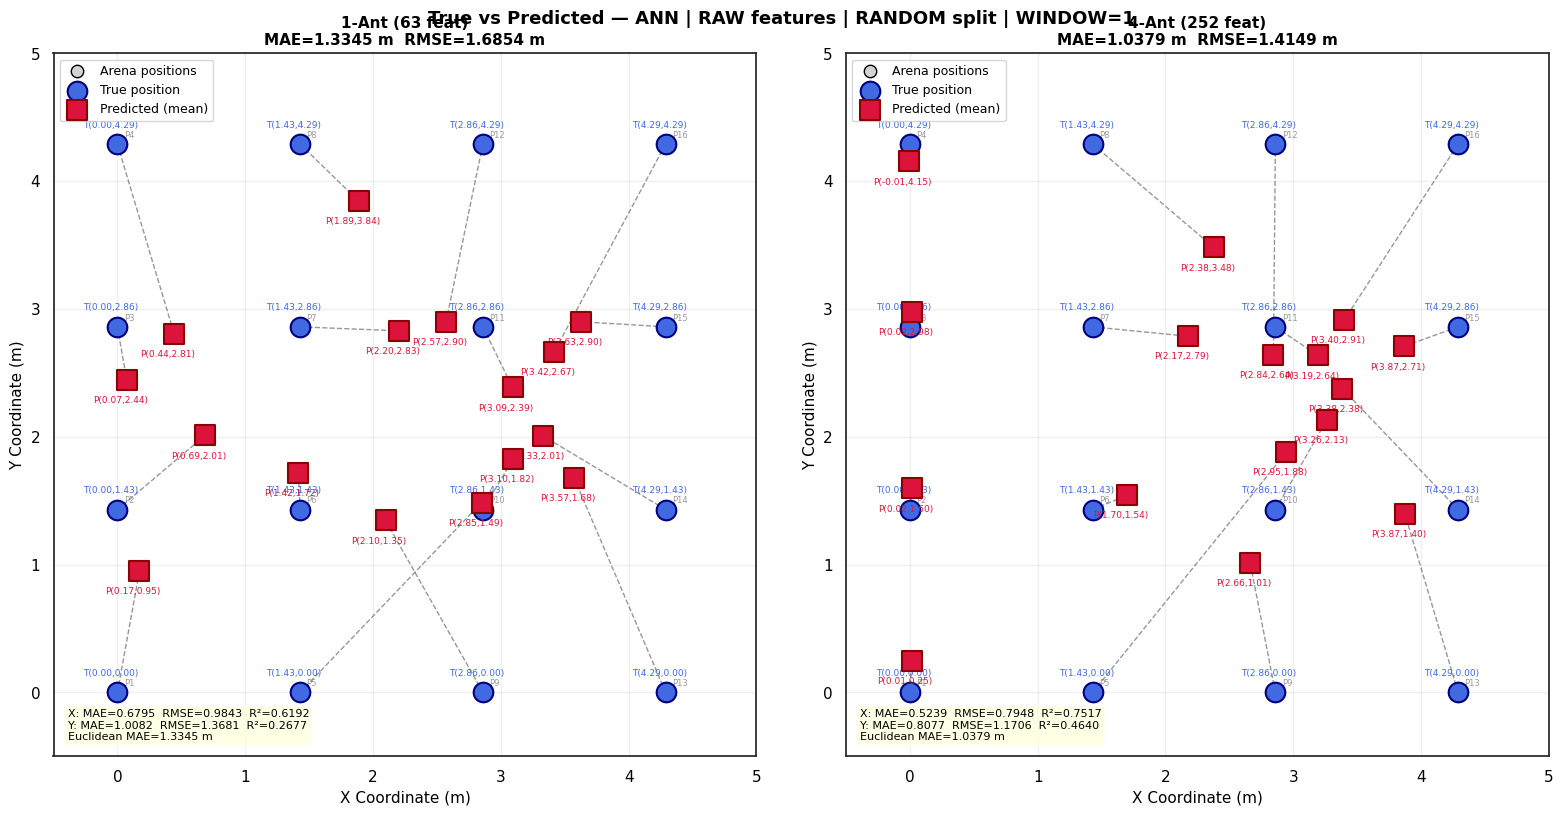

Saved: regression_scatter_ann_raw_random.png / .eps


In [11]:
sns.set_theme(style="white")
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white",
    "text.color":"black","axes.labelcolor":"black",
    "xtick.color":"black","ytick.color":"black","font.size":10
})

def plot_scatter(strategies_list, fig_title, filename):
    n = len(strategies_list)
    fig, axes = plt.subplots(1, n, figsize=(8*n, 8))
    if n == 1: axes = [axes]
    fig.suptitle(fig_title, fontsize=13, fontweight='bold')
    for ax, (metrics, centroids, title) in zip(axes, strategies_list):
        ax.scatter(arena_xs, arena_ys, s=80, color='lightgray',
                   edgecolor='black', label='Arena positions', zorder=1)
        for pos,(x,y) in POS_CONFIG.items():
            ax.text(x+0.05,y+0.05,pos.replace('pos','P'),fontsize=6,color='gray',alpha=0.8)
        ax.scatter(centroids['true_x'], centroids['true_y'],
                   s=200, color='royalblue', edgecolor='navy',
                   label='True position', zorder=3, linewidths=1.5)
        ax.scatter(centroids['pred_x_mean'], centroids['pred_y_mean'],
                   s=200, marker='s', color='crimson', edgecolor='darkred',
                   label='Predicted (mean)', zorder=4, linewidths=1.5)
        for _, row in centroids.iterrows():
            ax.plot([row['true_x'],row['pred_x_mean']],
                    [row['true_y'],row['pred_y_mean']],'k--',alpha=0.45,linewidth=1,zorder=2)
            ax.text(row['true_x']-0.05, row['true_y']+0.13,
                    f"T({row['true_x']:.2f},{row['true_y']:.2f})",
                    fontsize=6.5, color='royalblue', ha='center')
            ax.text(row['pred_x_mean']-0.05, row['pred_y_mean']-0.18,
                    f"P({row['pred_x_mean']:.2f},{row['pred_y_mean']:.2f})",
                    fontsize=6.5, color='crimson', ha='center')
        ax.set_xlabel('X Coordinate (m)', fontsize=11)
        ax.set_ylabel('Y Coordinate (m)', fontsize=11)
        ax.set_title(
            f'{title}\nMAE={metrics["mae_euc"]:.4f} m  RMSE={metrics["rmse_euc"]:.4f} m',
            fontsize=11, fontweight='bold')
        ax.legend(fontsize=9, loc='upper left')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.set_xlim(-0.5, 5.0)
        ax.set_ylim(-0.5, 5.0)
        mtxt = (f"X: MAE={metrics['mae_x']:.4f}  RMSE={metrics['rmse_x']:.4f}  R²={metrics['r2_x']:.4f}\n"
                f"Y: MAE={metrics['mae_y']:.4f}  RMSE={metrics['rmse_y']:.4f}  R²={metrics['r2_y']:.4f}\n"
                f"Euclidean MAE={metrics['mae_euc']:.4f} m")
        ax.text(0.02, 0.02, mtxt, transform=ax.transAxes, fontsize=8,
                verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    plt.tight_layout()
    for ext in ['png','eps']:
        plt.savefig(os.path.join(OUTPUT_DIR, f'{filename}.{ext}'),
                    dpi=150 if ext=='png' else None,
                    format=ext if ext=='eps' else None,
                    bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {filename}.png / .eps")

# Build strategy lists
ann_strats = [(m_ann_1, c_ann_1, f'1-Ant ({len(FEAT_1ANT)} feat)')]
if ENABLE_MRC:
    ann_strats.insert(1, (m_ann_mrc, c_ann_mrc, f'MRC ({len(FEAT_MRC)} feat)'))
ann_strats.append((m_ann_4, c_ann_4, f'4-Ant ({len(FEAT_4ANT)} feat)'))

plot_scatter(ann_strats,
    f'True vs Predicted — ANN | {FEATURE_TYPE.upper()} features | {SPLIT_TYPE.upper()} split | WINDOW={WINDOW}',
    f'regression_scatter_ann_{FEATURE_TYPE}_{SPLIT_TYPE}')

if ENABLE_RF:
    rf_strats = [(m_rf_1, c_rf_1, f'1-Ant ({len(FEAT_1ANT)} feat)')]
    if ENABLE_MRC:
        rf_strats.insert(1, (m_rf_mrc, c_rf_mrc, f'MRC ({len(FEAT_MRC)} feat)'))
    rf_strats.append((m_rf_4, c_rf_4, f'4-Ant ({len(FEAT_4ANT)} feat)'))
    plot_scatter(rf_strats,
        f'True vs Predicted — RF | {FEATURE_TYPE.upper()} features | {SPLIT_TYPE.upper()} split | WINDOW={WINDOW}',
        f'regression_scatter_rf_{FEATURE_TYPE}_{SPLIT_TYPE}')

## Step 12: Arena RMSE Heatmap

4×4 grid coloured by per-position RMSE. Dark blue = accurate, light = high error.

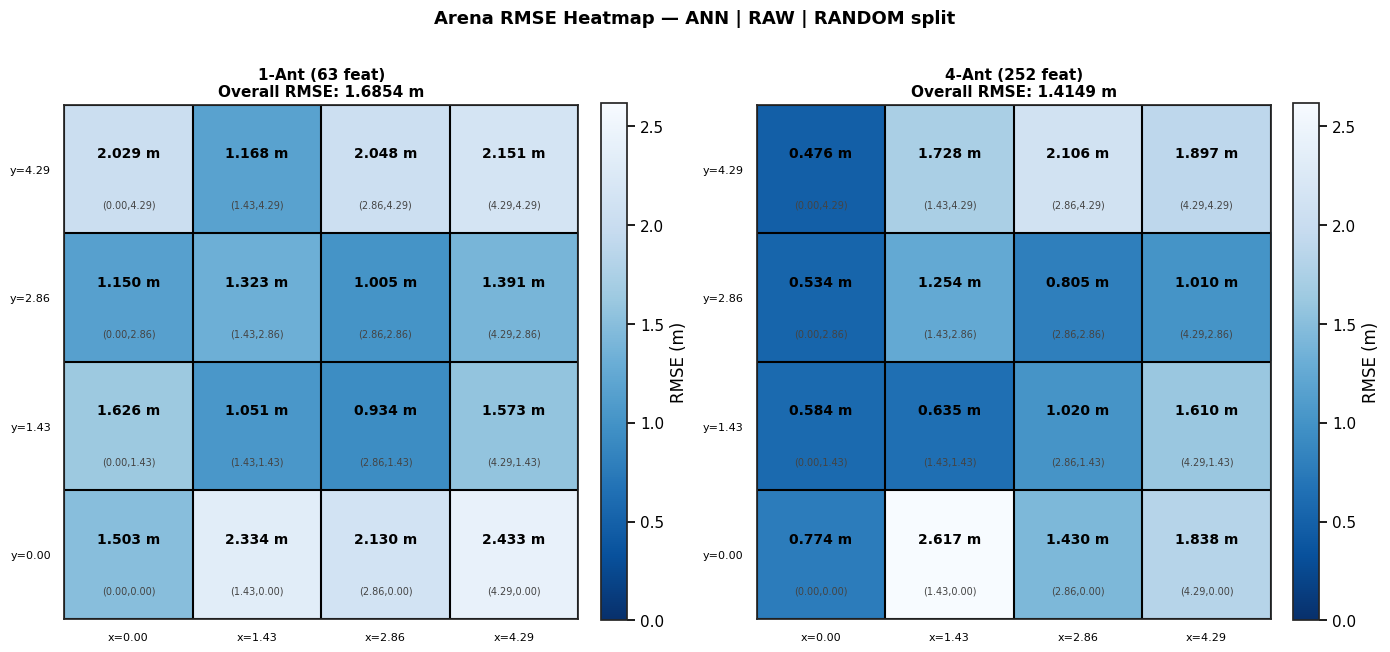

Saved: regression_heatmap_ann_raw_random.png / .eps


In [12]:
def plot_heatmap(strategies_list, fig_title, filename):
    n = len(strategies_list)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 7))
    if n == 1: axes = [axes]
    fig.suptitle(fig_title, fontsize=13, fontweight='bold')
    vmax = max(c['rmse_pos'].max() for _,c,_ in strategies_list)
    for ax, (metrics, centroids, title) in zip(axes, strategies_list):
        rmse_grid = np.full((4,4), np.nan)
        for _, row in centroids.iterrows():
            xi = round(row['true_x'] / 1.43)
            yi = round(row['true_y'] / 1.43)
            rmse_grid[3-yi, xi] = row['rmse_pos']
        im = ax.imshow(rmse_grid, cmap='Blues_r', aspect='equal', vmin=0, vmax=vmax)
        for r in range(4):
            for c_idx in range(4):
                if not np.isnan(rmse_grid[r, c_idx]):
                    val = rmse_grid[r, c_idx]
                    ax.text(c_idx, r-0.12, f'{val:.3f} m',
                            ha='center', va='center', fontsize=10, fontweight='bold', color='black')
                    ax.text(c_idx, r+0.28, f'({c_idx*1.43:.2f},{(3-r)*1.43:.2f})',
                            ha='center', va='center', fontsize=7, color='#444444')
        ax.set_xticks([0,1,2,3]); ax.set_yticks([0,1,2,3])
        ax.set_xticklabels(['x=0.00','x=1.43','x=2.86','x=4.29'], fontsize=8)
        ax.set_yticklabels(['y=4.29','y=2.86','y=1.43','y=0.00'], fontsize=8)
        ax.set_xticks(np.arange(-0.5,4,1), minor=True)
        ax.set_yticks(np.arange(-0.5,4,1), minor=True)
        ax.grid(which='minor', color='black', linewidth=1.5)
        ax.tick_params(which='minor', bottom=False, left=False)
        ax.set_title(f'{title}\nOverall RMSE: {metrics["rmse_euc"]:.4f} m',
                     fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('RMSE (m)')
    plt.tight_layout()
    for ext in ['png','eps']:
        plt.savefig(os.path.join(OUTPUT_DIR, f'{filename}.{ext}'),
                    dpi=150 if ext=='png' else None,
                    format=ext if ext=='eps' else None,
                    bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {filename}.png / .eps")

plot_heatmap(ann_strats,
    f'Arena RMSE Heatmap — ANN | {FEATURE_TYPE.upper()} | {SPLIT_TYPE.upper()} split',
    f'regression_heatmap_ann_{FEATURE_TYPE}_{SPLIT_TYPE}')

if ENABLE_RF:
    plot_heatmap(rf_strats,
        f'Arena RMSE Heatmap — RF | {FEATURE_TYPE.upper()} | {SPLIT_TYPE.upper()} split',
        f'regression_heatmap_rf_{FEATURE_TYPE}_{SPLIT_TYPE}')

## Step 13: ANN Training Loss Curves

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


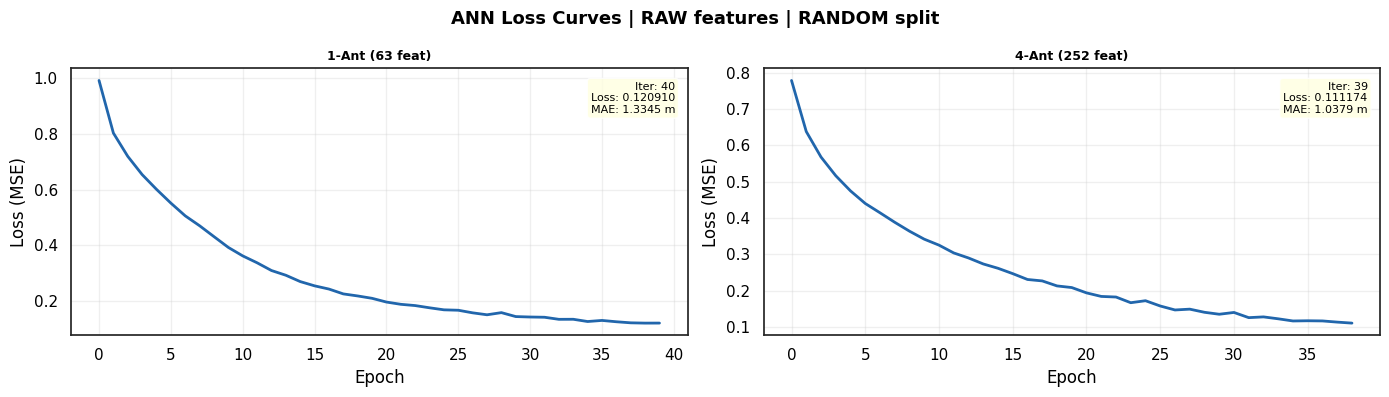

Saved: regression_loss_raw_random.png / .eps


In [13]:
fig, axes = plt.subplots(1, n_strat, figsize=(7*n_strat, 4))
if n_strat == 1: axes = [axes]
fig.suptitle(f'ANN Loss Curves | {FEATURE_TYPE.upper()} features | {SPLIT_TYPE.upper()} split',
             fontsize=13, fontweight='bold')
ann_regs = [ann_1ant]
if ENABLE_MRC: ann_regs.insert(1, ann_mrc)
ann_regs.append(ann_4ant)
for ax, (reg, (metrics, centroids, title)) in zip(axes, zip(ann_regs, ann_strats)):
    ax.plot(reg.loss_curve_, color='#2166ac', linewidth=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (MSE)')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.95,
            f'Iter: {reg.n_iter_}\nLoss: {reg.loss_:.6f}\nMAE: {metrics["mae_euc"]:.4f} m',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
for ext in ['png','eps']:
    plt.savefig(os.path.join(OUTPUT_DIR,
        f'regression_loss_{FEATURE_TYPE}_{SPLIT_TYPE}.{ext}'),
        dpi=150 if ext=='png' else None,
        format=ext if ext=='eps' else None,
        bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: regression_loss_{FEATURE_TYPE}_{SPLIT_TYPE}.png / .eps")

## Step 14: Final Results Summary

In [14]:
print("\n" + "="*75)
print("FINAL RESULTS SUMMARY — 16-Position Regression")
print("="*75)
print(f"  Hardware     : ASUS RT-AC86U | bcm4366c0 | 40MHz | WINDOW={WINDOW}")
print(f"  SPLIT_TYPE   : {SPLIT_TYPE}")
print(f"  FEATURE_TYPE : {FEATURE_TYPE}")
print(f"  Features     : 1-Ant={len(FEAT_1ANT)}  MRC={len(FEAT_MRC)}  4-Ant={len(FEAT_4ANT)}")
print(f"  {'─'*70}")
print(f"  {'Model + Strategy':<42} {'MAE (m)':<12} {'RMSE (m)':<12} {'R² X':<10} {'R² Y'}")
print(f"  {'─'*70}")

all_m = [m_ann_1]
if ENABLE_MRC: all_m.insert(1, m_ann_mrc)
all_m.append(m_ann_4)
if ENABLE_RF:
    all_m.append(m_rf_1)
    if ENABLE_MRC: all_m.append(m_rf_mrc)
    all_m.append(m_rf_4)

for m in all_m:
    print(f"  {m['label']:<42} {m['mae_euc']:<12.4f} {m['rmse_euc']:<12.4f} "
          f"{m['r2_x']:<10.4f} {m['r2_y']:.4f}")

print("="*75)
print(f"\nOutput files (in {OUTPUT_DIR}):")
print(f"  regression_scatter_ann_{FEATURE_TYPE}_{SPLIT_TYPE}.png/.eps")
print(f"  regression_heatmap_ann_{FEATURE_TYPE}_{SPLIT_TYPE}.png/.eps")
print(f"  regression_loss_{FEATURE_TYPE}_{SPLIT_TYPE}.png/.eps")
if ENABLE_RF:
    print(f"  regression_scatter_rf_{FEATURE_TYPE}_{SPLIT_TYPE}.png/.eps")
    print(f"  regression_heatmap_rf_{FEATURE_TYPE}_{SPLIT_TYPE}.png/.eps")


FINAL RESULTS SUMMARY — 16-Position Regression
  Hardware     : ASUS RT-AC86U | bcm4366c0 | 40MHz | WINDOW=1
  SPLIT_TYPE   : random
  FEATURE_TYPE : raw
  Features     : 1-Ant=63  MRC=63  4-Ant=252
  ──────────────────────────────────────────────────────────────────────
  Model + Strategy                           MAE (m)      RMSE (m)     R² X       R² Y
  ──────────────────────────────────────────────────────────────────────
  ANN — 1-Ant  (63 feat)                     1.3345       1.6854       0.6192     0.2677
  ANN — 4-Ant  (252 feat)                    1.0379       1.4149       0.7517     0.4640

Output files (in /home/azbil-new/localization):
  regression_scatter_ann_raw_random.png/.eps
  regression_heatmap_ann_raw_random.png/.eps
  regression_loss_raw_random.png/.eps
